# 1. Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import pickle

# 2. Загрузка данных

In [20]:
TRAIN_DIR = r"train_data"

### Находим все parquet-файлы train по маске и сортируем.

In [3]:
train_files = sorted(glob.glob(os.path.join(TRAIN_DIR, "train_data_*.pq")))
print("files:", len(train_files))
print(*train_files[:3], sep="\n")

files: 12
train_data\train_data_0.pq
train_data\train_data_1.pq
train_data\train_data_10.pq


# 3. Первичный анализ данных (до агрегации)

Данные представлены в событийном формате: одному клиенту соответствует несколько кредитов.

In [4]:
df0 = pd.read_parquet(train_files[0]) 

print("Размерность:", df0.shape)
df0.head()

Размерность: (1974724, 61)


,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,...,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
0,0,1,18,9,2,3,16,10,11,3,...,3,3,3,4,1,3,4,1,0,0
1,0,2,18,9,14,14,12,12,0,3,...,0,0,0,4,1,3,4,1,0,0
2,0,3,18,9,4,8,1,11,11,0,...,0,0,0,4,1,2,3,1,1,1
3,0,4,4,1,9,12,16,7,12,2,...,3,3,3,4,1,3,1,1,0,0
4,0,5,5,12,15,2,11,12,10,2,...,3,3,3,4,1,3,4,1,0,0


## Типы данных

In [5]:
print(df0.columns.tolist())
df0.dtypes.value_counts()

['id', 'rn', 'pre_since_opened', 'pre_since_confirmed', 'pre_pterm', 'pre_fterm', 'pre_till_pclose', 'pre_till_fclose', 'pre_loans_credit_limit', 'pre_loans_next_pay_summ', 'pre_loans_outstanding', 'pre_loans_total_overdue', 'pre_loans_max_overdue_sum', 'pre_loans_credit_cost_rate', 'pre_loans5', 'pre_loans530', 'pre_loans3060', 'pre_loans6090', 'pre_loans90', 'is_zero_loans5', 'is_zero_loans530', 'is_zero_loans3060', 'is_zero_loans6090', 'is_zero_loans90', 'pre_util', 'pre_over2limit', 'pre_maxover2limit', 'is_zero_util', 'is_zero_over2limit', 'is_zero_maxover2limit', 'enc_paym_0', 'enc_paym_1', 'enc_paym_2', 'enc_paym_3', 'enc_paym_4', 'enc_paym_5', 'enc_paym_6', 'enc_paym_7', 'enc_paym_8', 'enc_paym_9', 'enc_paym_10', 'enc_paym_11', 'enc_paym_12', 'enc_paym_13', 'enc_paym_14', 'enc_paym_15', 'enc_paym_16', 'enc_paym_17', 'enc_paym_18', 'enc_paym_19', 'enc_paym_20', 'enc_paym_21', 'enc_paym_22', 'enc_paym_23', 'enc_paym_24', 'enc_loans_account_holder_type', 'enc_loans_credit_status',

int64    61
Name: count, dtype: int64

Все признаки числовые но есть уже закодированные категориальные признаки

## Пропуски

In [6]:
missing = df0.isna().mean().sort_values(ascending=False)
missing.head(20)

id             0.0
enc_paym_1     0.0
enc_paym_3     0.0
enc_paym_4     0.0
enc_paym_5     0.0
enc_paym_6     0.0
enc_paym_7     0.0
enc_paym_8     0.0
enc_paym_9     0.0
enc_paym_10    0.0
enc_paym_11    0.0
enc_paym_12    0.0
enc_paym_13    0.0
enc_paym_14    0.0
enc_paym_15    0.0
enc_paym_16    0.0
enc_paym_17    0.0
enc_paym_18    0.0
enc_paym_19    0.0
enc_paym_20    0.0
dtype: float64

Пропуски в данных отсутствуют

## Проверка на повтор id

In [7]:
print("Количество строк:", df0.shape[0])
print("Уникальных id:", df0["id"].nunique())

Количество строк: 1974724
Уникальных id: 250000


**Вывод:** строк больше, чем уникальных id, значит, одному клиенту соответствует несколько кредитов. Требуется агрегация до уровня клиента.

## Проверка корректности rn

In [8]:
df0.groupby("id")["rn"].max().describe()

count    250000.000000
mean          7.898896
std           5.743369
min           1.000000
25%           3.000000
50%           7.000000
75%          11.000000
max          51.000000
Name: rn, dtype: float64

In [9]:
df0.sort_values(["id", "rn"]).head(20)

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,...,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
0,0,1,18,9,2,3,16,10,11,3,...,3,3,3,4,1,3,4,1,0,0
1,0,2,18,9,14,14,12,12,0,3,...,0,0,0,4,1,3,4,1,0,0
2,0,3,18,9,4,8,1,11,11,0,...,0,0,0,4,1,2,3,1,1,1
3,0,4,4,1,9,12,16,7,12,2,...,3,3,3,4,1,3,1,1,0,0
4,0,5,5,12,15,2,11,12,10,2,...,3,3,3,4,1,3,4,1,0,0
5,0,6,5,0,11,8,12,11,4,2,...,3,3,3,4,1,2,3,1,0,1
6,0,7,3,9,1,2,12,14,15,5,...,3,3,3,4,1,3,4,1,0,0
7,0,8,2,9,2,3,12,14,15,5,...,3,3,3,4,1,3,4,1,0,0
8,0,9,1,9,11,13,14,8,2,5,...,3,3,3,4,1,2,4,1,0,0
9,0,10,7,9,2,10,8,8,16,4,...,3,3,3,4,1,2,4,1,0,0


**Вывод:** rn действительно является порядковым номером кредита клиента и может использоваться для расчёта количества кредитов и признаков “последнего кредита”.


## Распределение количества кредитов на клиента

C:\Users\Мария\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


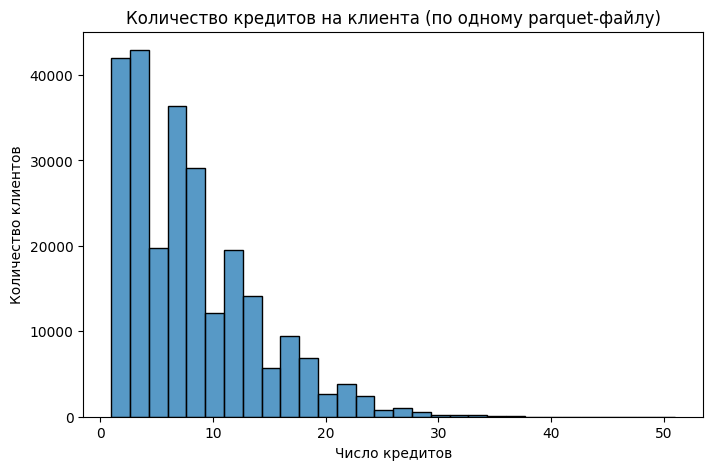

In [10]:
loans_per_client = df0.groupby("id")["rn"].max()

plt.figure(figsize=(8,5))
sns.histplot(loans_per_client, bins=30)
plt.title("Количество кредитов на клиента (по одному parquet-файлу)")
plt.xlabel("Число кредитов")
plt.ylabel("Количество клиентов")
plt.show()

**Вывод:** большинство клиентов имеют небольшое число кредитов, но присутствует хвост “многокредитных” клиентов. Важно использовать агрегации (mean/max/sum) и отдельно учитывать количество кредитов.

## Типы колонок по префиксам

In [11]:
pre_cols = [c for c in df0.columns if c.startswith("pre_")]
enc_cols = [c for c in df0.columns if c.startswith("enc_")]
flag_cols = [c for c in df0.columns if ("flag" in c) or c.startswith("is_zero_")]

len(pre_cols), len(enc_cols), len(flag_cols)

(20, 29, 10)

**Вывод:**  
- pre_* — числовые (бинаризованные интервалы)  
- enc_* — закодированные категории  
- flag/is_zero_* — бинарные индикаторы  
Это определяет подход к агрегации: числовые → mean/max/sum, категории → mode/last.

## Ключевые “рисковые” признаки: распределения

In [12]:
for col in ["pre_util", "pre_loans_total_overdue", "pre_loans90"]:
    print("\n", col)
    print("nunique:", df0[col].nunique(), "min:", df0[col].min(), "max:", df0[col].max())
    display(df0[col].value_counts(normalize=True).sort_index().head(15))


 pre_util
nunique: 20 min: 0 max: 19


pre_util
0     0.010163
1     0.012656
2     0.009098
3     0.034896
4     0.010197
5     0.008964
6     0.019683
7     0.011050
8     0.009465
9     0.054182
10    0.010573
11    0.017251
12    0.010337
13    0.009177
14    0.000769
Name: proportion, dtype: float64


 pre_loans_total_overdue
nunique: 1 min: 0 max: 0


pre_loans_total_overdue
0    1.0
Name: proportion, dtype: float64


 pre_loans90
nunique: 4 min: 8 max: 19


pre_loans90
8     0.999818
13    0.000025
14    0.000152
19    0.000004
Name: proportion, dtype: float64

**Вывод:** признаки разреженные и дискретные (код интервала). В качестве агрегатов будут полезны `max` (худший случай) и `sum`/`mean` (накопленный/средний риск).

### Оценка памяти

In [13]:
mem_mb = df0.memory_usage(deep=True).sum() / 1024**2
print(f"df0 RAM ~ {mem_mb:.1f} MB")

df0 RAM ~ 919.0 MB


# 4. Агрегация и сохранение датасета

In [14]:
paym_cols = [f"enc_paym_{i}" for i in range(25)]
loan_cat_cols = [
    "enc_loans_account_holder_type",
    "enc_loans_credit_status",
    "enc_loans_credit_type",
    "enc_loans_account_cur",
]

BATCH_SIZE = 2 
parts = []
last_parts = []

for i in range(0, len(train_files), BATCH_SIZE):
    batch_files = train_files[i:i + BATCH_SIZE]

    if len(batch_files) == 1:
        df = pd.read_parquet(batch_files[0])
    else:
        df = pd.concat([pd.read_parquet(f) for f in batch_files], ignore_index=True)

    df["id"] = df["id"].astype("int32")
    df["rn"] = df["rn"].astype("int16")

    enc_cols = [c for c in df.columns if c.startswith("enc_")]
    
    g = df.groupby("id", sort=False)

    features = g.agg(
        loans_cnt=("rn", "size"),  
        rn_max=("rn", "max"),     
        rn_min=("rn", "min"),
    ).reset_index()

    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in ["id", "rn"] and c not in enc_cols]

    # считаем только sum/count/min/max (их можно корректно склеивать между батчами)
    if numeric_cols:
        num = g[numeric_cols].agg(["sum", "count", "min", "max"])
        num.columns = [f"{col}_{stat}" for col, stat in num.columns]
        num = num.reset_index()
        features = features.merge(num, on="id", how="left")

    # loan_cat_cols: считаем только count 
    present_loan_cat = [c for c in loan_cat_cols if c in df.columns]
    if present_loan_cat:
        loan_aggs = {f"{col}_cnt": (col, "count") for col in present_loan_cat}
        loan_df = g.agg(**loan_aggs).reset_index()
        features = features.merge(loan_df, on="id", how="left")

    # платежные признаки: obs/bad и их суммы по id 
    present_paym = [c for c in paym_cols if c in df.columns]
    if present_paym:
        X = df[present_paym]

        # obs_row = сколько из 25 статусов наблюдаемо в этой строке
        # bad_row = сколько наблюдаемых != 0 (трактуем как "плохие")
        obs_row = X.notna().sum(axis=1).astype("int32")
        bad_row = (X.notna() & X.ne(0)).sum(axis=1).astype("int32")

        tmp = pd.DataFrame({"id": df["id"].values,
                            "paym_obs": obs_row.values,
                            "paym_bad": bad_row.values})
        paym_df = tmp.groupby("id", sort=False).sum().reset_index()

        # share внутри батча НЕ финализируем, финализируем после глобального суммирования
        features = features.merge(paym_df, on="id", how="left")

    # last внутри батча (по максимальному rn) 
    idx = g["rn"].idxmax()
    last_rows = df.loc[idx, ["id", "rn"] + enc_cols].copy()
    last_rows = last_rows.rename(columns={c: f"last__{c}" for c in enc_cols})
    last_parts.append(last_rows)

    parts.append(features)
    print("batch", i // BATCH_SIZE, "->", features.shape)

# склеиваем батчи 
all_features = pd.concat(parts, ignore_index=True)

#  финальная агрегация по id 
agg = {"loans_cnt": "sum", "rn_max": "max", "rn_min": "min"}

for c in all_features.columns:
    if c in ("id", "loans_cnt", "rn_max", "rn_min"):
        continue

    if c.endswith(("_sum", "_count", "_cnt")):
        agg[c] = "sum"
    elif c.endswith("_min"):
        agg[c] = "min"
    elif c.endswith("_max"):
        agg[c] = "max"
    elif c in ("paym_obs", "paym_bad"):
        agg[c] = "sum"
    else:
        pass

final_features = all_features.groupby("id", as_index=False).agg(agg)

# считаем mean для numeric из sum/count 
sum_cols = [c for c in final_features.columns if c.endswith("_sum")]
for s in sum_cols:
    base = s[:-4]
    cnt = base + "_count"
    if cnt in final_features.columns:
        final_features[base + "_mean"] = final_features[s] / final_features[cnt].replace(0, np.nan)

# финализируем paym_bad_share после глобальных сумм 
if "paym_obs" in final_features.columns and "paym_bad" in final_features.columns:
    final_features["paym_obs_is0"] = (final_features["paym_obs"].fillna(0) == 0).astype("int8")
    final_features["paym_bad_share"] = (
        final_features["paym_bad"] / final_features["paym_obs"].replace(0, np.nan)
    ).fillna(0.0).astype("float32")

# глобальный last по всем батчам 
all_last = pd.concat(last_parts, ignore_index=True)
idx_global = all_last.groupby("id")["rn"].idxmax()
global_last = all_last.loc[idx_global].drop(columns=["rn"]).copy()

# финальный датасет
dataset = final_features.merge(global_last, on="id", how="left")
print("dataset:", dataset.shape)
dataset.head()

batch 0 -> (500000, 130)
batch 1 -> (500000, 130)
batch 2 -> (500000, 130)
batch 3 -> (500000, 130)
batch 4 -> (500000, 130)
batch 5 -> (500000, 130)
dataset: (3000000, 191)


,id,loans_cnt,rn_max,rn_min,pre_since_opened_sum,pre_since_opened_count,pre_since_opened_min,pre_since_opened_max,pre_since_confirmed_sum,pre_since_confirmed_count,...,last__enc_paym_19,last__enc_paym_20,last__enc_paym_21,last__enc_paym_22,last__enc_paym_23,last__enc_paym_24,last__enc_loans_account_holder_type,last__enc_loans_credit_status,last__enc_loans_credit_type,last__enc_loans_account_cur
0,0,10,10,1,81,10,1,18,76,10,...,3,4,3,3,3,4,1,2,4,1
1,1,14,14,1,160,14,2,18,107,14,...,3,4,3,3,3,4,1,2,3,1
2,2,3,3,1,25,3,0,13,32,3,...,3,4,3,3,3,4,1,2,3,1
3,3,15,15,1,105,15,1,18,110,15,...,3,4,3,3,3,4,1,2,4,1
4,4,1,1,1,12,1,12,12,9,1,...,3,4,3,3,3,4,1,2,3,1


## Агрегация событийных данных до уровня клиента
Исходные данные представлены в формате событий: одному клиенту (`id`) соответствует несколько наблюдений, упорядоченных по индексу `rn`.
Цель данного блока — преобразовать событийную таблицу в клиентскую, где каждой строке соответствует один клиент.

## Подход
Обработка выполняется батчами (по parquet-файлам) для контроля использования памяти.
Для каждого клиента рассчитываются следующие группы признаков:

1. **Структура истории:**
   - `loans_cnt` — количество наблюдений (длина истории);
   - `rn_min`, `rn_max` — диапазон временного индекса.

2. **Числовые признаки (кроме enc_):**
   - `sum`, `count`, `min`, `max`;
   - `mean` рассчитывается после финальной агрегации как `sum / count`,
     что обеспечивает корректное объединение между батчами.

3. **Категориальные loan-признаки:**
   - рассчитывается количество наблюдений (`count`);
   - `nunique` не используется в baseline-версии, поскольку его нельзя
     корректно агрегировать между файлами простой операцией.

4. **Платёжные признаки:**
   - `paym_obs` — количество наблюдаемых платёжных статусов;
   - `paym_bad` — количество статусов, отличных от 0 (интерпретируются как отклонения от нормы);
   - `paym_bad_share` — доля проблемных статусов;
   - `paym_obs_is0` — индикатор отсутствия платёжной истории.

5. **Текущее состояние клиента:**
   - `last__enc_*` — значения признаков в последнем наблюдении
     (определяется глобально по максимальному `rn`).

## Результат

Получен агрегированный датасет уровня клиента, объединяющий:
- характеристики истории,
- статистики числовых признаков,
- платёжную дисциплину,
- текущее состояние клиента.

Данный датасет используется как вход для построения модели кредитного риска.


### Сохранение датасета

In [15]:
dataset.to_parquet("final_features.parquet", index=False)

# 5. EDA после агрегации

Анализ распределения признаков и их связи с дефолтом.

## Загрузка подготовленного датасета без повторного чтения исходных данных

In [2]:
dataset = pd.read_parquet("final_features.parquet")

## Проверка структуры

In [3]:
print("Shape:", dataset.shape)
print("\nDtypes:")
print(dataset.dtypes.value_counts())

print("\nПропуски (top 20):")
display(dataset.isna().mean().sort_values(ascending=False).head(20))

print("\nКоличество константных колонок:")
const_cols = [c for c in dataset.columns if dataset[c].nunique(dropna=False) <= 1]
print(len(const_cols))

Shape: (3000000, 191)

Dtypes:
int64      154
float64     30
int32        3
int16        2
int8         1
float32      1
Name: count, dtype: int64

Пропуски (top 20):


id                                   0.0
pre_since_confirmed_mean             0.0
fclose_flag_min                      0.0
fclose_flag_max                      0.0
enc_loans_account_holder_type_cnt    0.0
enc_loans_credit_status_cnt          0.0
enc_loans_credit_type_cnt            0.0
enc_loans_account_cur_cnt            0.0
paym_obs                             0.0
paym_bad                             0.0
pre_since_opened_mean                0.0
pre_pterm_mean                       0.0
fclose_flag_sum                      0.0
pre_fterm_mean                       0.0
pre_till_pclose_mean                 0.0
pre_till_fclose_mean                 0.0
pre_loans_credit_limit_mean          0.0
pre_loans_next_pay_summ_mean         0.0
pre_loans_outstanding_mean           0.0
pre_loans_total_overdue_mean         0.0
dtype: float64


Количество константных колонок:
2


### Проверка итогового агрегированного датасета
- Размерность датасета: ~3 млн клиентов и 191 признак.
- Все признаки имеют числовой тип, категориальные признаки представлены в закодированном виде.
- Пропуски в данных отсутствуют, что подтверждает корректность агрегации и обработки делений.
- Обнаружено 2 константных признака, которые будут удалены перед обучением модели.

Таким образом, итоговый датасет является корректным и готовым к построению baseline-модели.

In [4]:
const_cols = [c for c in dataset.columns if dataset[c].nunique(dropna=False) <= 1]
dataset = dataset.drop(columns=const_cols)

## Объединение с таргетом

In [5]:
target = pd.read_csv("train_target.csv")
dataset = dataset.merge(target, on="id", how="inner")

In [6]:
dataset.shape

(3000000, 190)

In [7]:
dataset.head()

,id,loans_cnt,rn_max,pre_since_opened_sum,pre_since_opened_count,pre_since_opened_min,pre_since_opened_max,pre_since_confirmed_sum,pre_since_confirmed_count,pre_since_confirmed_min,...,last__enc_paym_20,last__enc_paym_21,last__enc_paym_22,last__enc_paym_23,last__enc_paym_24,last__enc_loans_account_holder_type,last__enc_loans_credit_status,last__enc_loans_credit_type,last__enc_loans_account_cur,flag
0,0,10,10,81,10,1,18,76,10,0,...,4,3,3,3,4,1,2,4,1,0
1,1,14,14,160,14,2,18,107,14,3,...,4,3,3,3,4,1,2,3,1,0
2,2,3,3,25,3,0,13,32,3,9,...,4,3,3,3,4,1,2,3,1,0
3,3,15,15,105,15,1,18,110,15,0,...,4,3,3,3,4,1,2,4,1,0
4,4,1,1,12,1,12,12,9,1,9,...,4,3,3,3,4,1,2,3,1,0


In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Columns: 190 entries, id to flag
dtypes: float32(1), float64(30), int16(1), int32(3), int64(155)
memory usage: 4.2 GB


## Проверка баланса классов

In [9]:
dataset['flag'].value_counts(normalize=True).rename('share').to_frame()

,share
flag,
0,0.964519
1,0.035481


## Распределение ключевых принаков

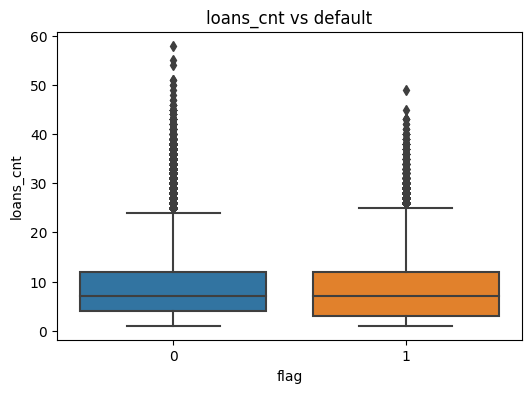

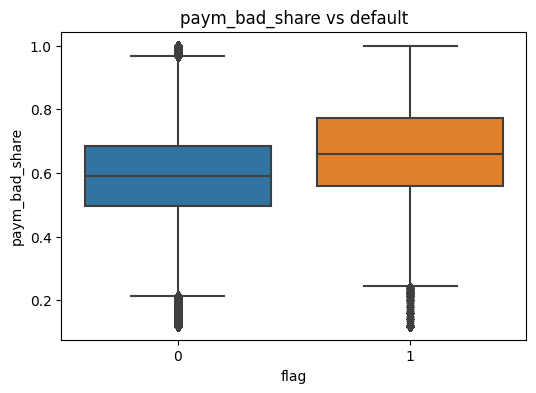

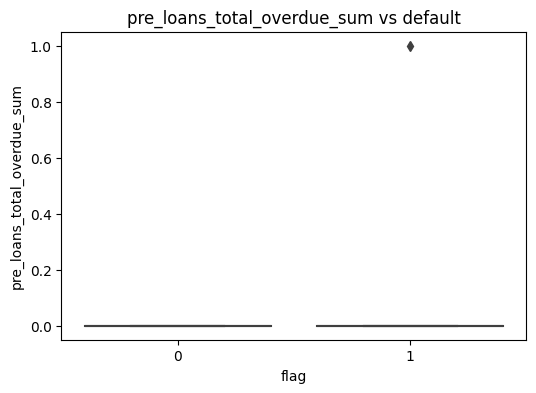

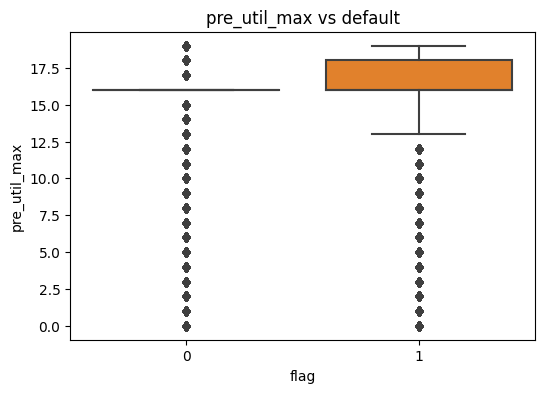

In [10]:
important_cols = [
    "loans_cnt",
    "paym_bad_share",
    "pre_loans_total_overdue_sum",
    "pre_util_max",
]

for col in important_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="flag", y=col, data=dataset)
    plt.title(f"{col} vs default")
    plt.show()


### Анализ распределения ключевых признаков

1. loans_cnt (количество кредитов в истории клиента)
У дефолтных клиентов медианное значение немного выше, однако распределения классов существенно перекрываются. Это указывает на то, что признак обладает слабой индивидуальной разделяющей способностью, но может быть полезен в комбинации с другими факторами риска.

2. paym_bad_share (доля проблемных платёжных статусов)
Наблюдается чёткое смещение распределения у дефолтных клиентов в сторону более высоких значений. Данный признак демонстрирует выраженную связь с вероятностью дефолта и является одним из наиболее информативных факторов в модели.

3. pre_loans_total_overdue_sum (суммарные просрочки)
Распределение показывает практически полное отсутствие вариативности — большинство значений равно нулю. Признак близок к константному и в текущем виде вряд ли будет вносить значимый вклад в модель. Требуется дополнительная проверка целесообразности его использования.

4. pre_util_max (максимальный уровень кредитной нагрузки)
У дефолтных клиентов наблюдаются систематически более высокие значения. Признак демонстрирует хорошую разделяющую способность и отражает экономически обоснованный риск-фактор: высокая кредитная нагрузка связана с большей вероятностью дефолта.

### Анализ pre_loans_total_overdue_sum

In [11]:
col = "pre_loans_total_overdue_sum"
zero_rate = (dataset[col] == 0).mean()
nuniq = dataset[col].nunique(dropna=False)

print(f"{col}: zero_rate={zero_rate:.4f}, nunique={nuniq}")
print("Top values:")
display(dataset[col].value_counts().head(10))

desc = dataset.groupby("flag")[col].describe(percentiles=[0.5, 0.9, 0.99])
display(desc[["mean", "50%", "90%", "99%"]])

pre_loans_total_overdue_sum: zero_rate=1.0000, nunique=2
Top values:


pre_loans_total_overdue_sum
0    2999999
1          1
Name: count, dtype: int64

,mean,50%,90%,99%
flag,,,,
0,0.000000,0.0,0.0,0.0
1,0.000009,0.0,0.0,0.0


### Новые признаки

In [12]:
# Бинарный флаг "есть плохие платежи"
dataset["has_bad_paym"] = (dataset["paym_bad_share"] > 0).astype("int8")

# Флаг высокой утилизации (90-й перцентиль как адаптивный порог)
util_thr = dataset["pre_util_max"].quantile(0.90)
dataset["high_util_flag"] = (dataset["pre_util_max"] >= util_thr).astype("int8")

print("Added:", ["has_any_overdue", "has_bad_paym", "high_util_flag"])
print("util_thr:", util_thr)

Added: ['has_any_overdue', 'has_bad_paym', 'high_util_flag']
util_thr: 18.0


In [13]:
col = "pre_loans_total_overdue_sum"
zero_rate = (dataset[col] == 0).mean()

if zero_rate > 0.995:
    dataset = dataset.drop(columns=[col])
    print(f"Dropped {col} because it is near-constant (zero_rate={zero_rate:.4f}).")
else:
    print(f"Kept {col} (zero_rate={zero_rate:.4f})")

Dropped pre_loans_total_overdue_sum because it is near-constant (zero_rate=1.0000).


## Корреляция с таргетом

In [14]:
sample_corr = dataset.sample(200_000, random_state=42)
corr_cols = [
    c for c in sample_corr.columns
    if c.startswith(("pre_", "paym_", "loans_", "rn_"))
]

corr_cols = ["flag"] + corr_cols

corr = sample_corr[corr_cols].corr(numeric_only=True)["flag"].sort_values(ascending=False)

print("Top-15 положительных корреляций:")
display(corr.head(15))

print("Top-15 отрицательных корреляций:")
display(corr.tail(15))

Top-15 положительных корреляций:


flag                           1.000000
paym_bad_share                 0.085871
pre_since_opened_min           0.036327
pre_loans_credit_limit_min     0.031864
pre_loans_credit_limit_mean    0.027388
pre_over2limit_mean            0.024998
pre_till_pclose_min            0.023920
pre_fterm_min                  0.023592
pre_till_fclose_min            0.022354
pre_loans_outstanding_mean     0.021230
pre_pterm_min                  0.020053
pre_since_opened_mean          0.018835
pre_over2limit_max             0.018232
pre_loans_outstanding_max      0.017772
pre_loans90_max                0.017260
Name: flag, dtype: float64

Top-15 отрицательных корреляций:


pre_maxover2limit_max            -0.018896
pre_loans5_mean                  -0.019764
pre_till_pclose_max              -0.019887
pre_pterm_max                    -0.020000
pre_loans_credit_cost_rate_max   -0.020470
pre_util_max                     -0.022772
pre_loans5_min                   -0.023298
pre_fterm_max                    -0.026494
pre_loans_max_overdue_sum_min    -0.031155
pre_maxover2limit_mean           -0.034738
pre_util_mean                    -0.043159
pre_loans_total_overdue_min            NaN
pre_loans_total_overdue_max            NaN
pre_loans6090_max                      NaN
pre_loans_total_overdue_mean           NaN
Name: flag, dtype: float64

Линейная связь большинства признаков с дефолтом является слабой
Наибольшую положительную корреляцию демонстрирует paym_bad_share (r ≈ 0.086)
Остальные признаки обладают слабой линейной связью с таргетом, что может объясняться нелинейным характером зависимости между признаками и вероятностью дефолта.

## Анализ долей нулей

In [37]:
X_tmp = dataset.drop(columns=["id", "flag"])

zero_share = (X_tmp == 0).mean().sort_values(ascending=False)

print("Top-20 самых разреженных признаков:")
display(zero_share.head(20))

Top-20 самых разреженных признаков:


pre_loans_total_overdue_min     1.000000
pre_loans_total_overdue_mean    1.000000
pre_loans_total_overdue_max     1.000000
has_any_overdue                 1.000000
pclose_flag_min                 0.969191
fclose_flag_min                 0.943851
is_zero_util_min                0.905868
last__enc_paym_0                0.884339
high_util_flag                  0.759458
last__enc_paym_1                0.746859
last__enc_paym_2                0.649115
is_zero_maxover2limit_min       0.592879
is_zero_loans530_min            0.566078
last__enc_paym_3                0.560080
last__enc_paym_4                0.484983
last__enc_paym_5                0.419661
is_zero_over2limit_min          0.397831
is_zero_loans5_min              0.395350
last__enc_paym_6                0.360190
pre_fterm_min                   0.348349
dtype: float64

## Анализ last-признаков

In [16]:
last_cols = [c for c in dataset.columns if c.startswith("last__enc_paym_")]

print("Количество last__enc_paym_ колонок:", len(last_cols))

for col in last_cols[:3]: 
    print(f"\nDefault rate by {col}:")
    display(
        dataset.groupby(col)["flag"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

Количество last__enc_paym_ колонок: 25

Default rate by last__enc_paym_0:


last__enc_paym_0
2    0.116387
1    0.074144
3    0.054489
0    0.032151
Name: flag, dtype: float64


Default rate by last__enc_paym_1:


last__enc_paym_1
2    0.112046
1    0.067589
3    0.051873
0    0.029027
Name: flag, dtype: float64


Default rate by last__enc_paym_2:


last__enc_paym_2
2    0.123465
1    0.063907
3    0.048321
0    0.027620
Name: flag, dtype: float64

Выраженные различия в уровне дефолта между категориями
Например, для last__enc_paym_0 доля дефолта варьируется от ~3% до ~11% в зависимости от категории. Текущее состояние клиента является значимым фактором риска.
Использование last-признаков в модели является обоснованным и позволяет учитывать актуальный статус клиента, а не только агрегированные исторические показатели.

## Проверка на выбросы

In [18]:
key_cols = [
    "loans_cnt",
    "paym_bad_share",
    "pre_util_max"
]

key_cols = [c for c in key_cols if c in dataset.columns]

display(
    dataset[key_cols].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).T
)

,count,mean,std,min,1%,5%,50%,95%,99%,max
loans_cnt,3000000.0,8.720906,6.176249,1.00,1.00,1.000000,7.000,21.000000,26.00,58.0
paym_bad_share,3000000.0,0.591540,0.156868,0.12,0.12,0.333333,0.592,0.858182,0.96,1.0
pre_util_max,3000000.0,16.068631,2.538212,0.00,3.00,12.000000,16.000,19.000000,19.00,19.0


Анализ квантилей ключевых признаков (loans_cnt, paym_bad_share, pre_util_max) показал отсутствие экстремальных аномальных значений.

Для признака loans_cnt наблюдается естественный длинный хвост (до 58 кредитов), однако 99% наблюдений находятся в диапазоне до 26, что не требует дополнительной корректировки.

Признак paym_bad_share ограничен диапазоном [0,1] и не содержит аномальных значений.

Признак pre_util_max имеет дискретную шкалу с верхней границей 19, что исключает наличие экстремальных выбросов.

Таким образом, дополнительная обработка выбросов в baseline-версии модели не требуется.

In [39]:
dataset["util_x_bad"] = dataset["pre_util_max"] * dataset["paym_bad_share"]

dataset["bad_per_loan"] = dataset["paym_bad_share"] / (dataset["loans_cnt"] + 1)

dataset["high_risk_combo"] = (
    (dataset["pre_util_max"] > 15) &
    (dataset["paym_bad_share"] > 0.7)
).astype(int)

## Сохранение датасета

In [40]:
dataset.to_parquet("dataset_after_eda.parquet", index=False)

# 6. Модели и оценка качества

## Загрузка финального датасета

In [2]:
dataset = pd.read_parquet("dataset_after_eda.parquet")

In [3]:
print(dataset.shape)
print(dataset.columns[:10].tolist())

(3000000, 194)
['id', 'loans_cnt', 'rn_max', 'pre_since_opened_sum', 'pre_since_opened_count', 'pre_since_opened_min', 'pre_since_opened_max', 'pre_since_confirmed_sum', 'pre_since_confirmed_count', 'pre_since_confirmed_min']


## Проверка баланса классов 

In [4]:
flag_share = dataset["flag"].value_counts(normalize=True)
print(flag_share)

flag
0    0.964519
1    0.035481
Name: proportion, dtype: float64


Доля дефолта в выборке составляет около 3,5%, что указывает на выраженный дисбаланс классов.

В условиях дисбаланса метрика accuracy не является информативной, поскольку модель, предсказывающая только недефолтные случаи, может демонстрировать высокую точность при полном отсутствии практической ценности.

В качестве основной метрики качества выбрана ROC-AUC

## Разделение на признаки и target

In [5]:
X = dataset.drop(columns=["id", "flag"])
y = dataset["flag"]

In [6]:
print("X shape:", X.shape, "y shape:", y.shape)

X shape: (3000000, 192) y shape: (3000000,)


## Train/Test split

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (2400000, 192) Test: (600000, 192)


In [8]:
print("\nTrain")
print(y_train.value_counts(normalize=True))

print("\nTest")
print(y_test.value_counts(normalize=True))


Train
flag
0    0.964519
1    0.035481
Name: proportion, dtype: float64

Test
flag
0    0.96452
1    0.03548
Name: proportion, dtype: float64


## Logistic Regression + ROC-AUC

In [34]:
logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced"
    ))
])

logreg_pipe.fit(X_train, y_train)

proba_lr = logreg_pipe.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, proba_lr)

print("Baseline LogisticRegression ROC-AUC:", auc_lr)

Baseline LogisticRegression ROC-AUC: 0.7121141841637504


Kогистическая регрессия с масштабированием признаков и балансировкой классов (class_weight="balanced").
Полученное значение ROC-AUC на тестовой выборке составило 0.71.

Данный результат показывает, что линейная модель улавливает часть закономерностей в данных, однако её качество недостаточно

## HistGradientBoosting

In [37]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.05,
    max_iter=200,
    random_state=42
)

hgb.fit(X_train, y_train)

proba_hgb = hgb.predict_proba(X_test)[:, 1]
auc_hgb = roc_auc_score(y_test, proba_hgb)

print("HistGradientBoosting ROC-AUC:", auc_hgb)

HistGradientBoosting ROC-AUC: 0.7411982897033029


In [48]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb2 = HistGradientBoostingClassifier(
    max_depth=8,
    learning_rate=0.03,
    max_iter=350,
    min_samples_leaf=50,
    random_state=42
)

hgb2.fit(X_train, y_train)

proba_hgb2 = hgb2.predict_proba(X_test)[:, 1]
auc_hgb2 = roc_auc_score(y_test, proba_hgb2)

print("Improved HGB ROC-AUC:", auc_hgb2)

Improved HGB ROC-AUC: 0.7421382263253277


## тюнинг

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

RANDOM_STATE = 42

N_TUNE = 300_000

idx = X_train.sample(n=min(N_TUNE, len(X_train)), random_state=RANDOM_STATE).index
X_tune = X_train.loc[idx]
y_tune = y_train.loc[idx]

print("Tune sample:", X_tune.shape)

base_hgb = HistGradientBoostingClassifier(
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.1
)

param_dist = {
    "max_depth": [6, 8, None],
    "learning_rate": [0.03, 0.05],
    "max_iter": [250, 400],
    "min_samples_leaf": [50, 100],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=base_hgb,
    param_distributions=param_dist,
    n_iter=6,             
    scoring="roc_auc",
    cv=cv,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=1              
)

search.fit(X_tune, y_tune)

print("\nBest CV ROC-AUC:", search.best_score_)
print("Best params:", search.best_params_)

best_hgb = search.best_estimator_

# финальная оценка на test
best_hgb.fit(X_train, y_train)

proba_best = best_hgb.predict_proba(X_test)[:, 1]
auc_best = roc_auc_score(y_test, proba_best)

print("\nTuned HGB ROC-AUC (test):", auc_best)

Tune sample: (300000, 192)
Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END learning_rate=0.03, max_depth=None, max_iter=250, min_samples_leaf=50; total time=  22.5s
[CV] END learning_rate=0.03, max_depth=None, max_iter=250, min_samples_leaf=50; total time=  24.0s
[CV] END learning_rate=0.03, max_depth=None, max_iter=250, min_samples_leaf=50; total time=  20.8s
[CV] END learning_rate=0.05, max_depth=8, max_iter=250, min_samples_leaf=50; total time=  18.0s
[CV] END learning_rate=0.05, max_depth=8, max_iter=250, min_samples_leaf=50; total time=  13.6s
[CV] END learning_rate=0.05, max_depth=8, max_iter=250, min_samples_leaf=50; total time=  13.6s
[CV] END learning_rate=0.03, max_depth=6, max_iter=250, min_samples_leaf=50; total time=  20.7s
[CV] END learning_rate=0.03, max_depth=6, max_iter=250, min_samples_leaf=50; total time=  23.1s
[CV] END learning_rate=0.03, max_depth=6, max_iter=250, min_samples_leaf=50; total time=  15.5s
[CV] END learning_rate=0.05, max_depth=8

Для HistGradientBoosting была проведена попытка подбора гиперпараметров, однако существенного улучшения ROC-AUC не получено. Это указывает, что качество модели ограничено информативностью текущих признаков

In [9]:
!pip -q install lightgbm


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import lightgbm as lgb

RANDOM_STATE = 42

X = dataset.drop(columns=["id", "flag"])
y = dataset["flag"]

cat_cols = [c for c in X.columns if c.startswith("enc_") or c.startswith("last__enc_")]
num_cols = [c for c in X.columns if c not in cat_cols]

print("X shape:", X.shape)
print("cat:", len(cat_cols), "num:", len(num_cols))
print("Default rate:", y.mean())

X[cat_cols] = X[cat_cols].astype("int32").astype("category")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Test:", X_test.shape)

X shape: (3000000, 192)
cat: 33 num: 159
Default rate: 0.03548066666666667
Train: (2400000, 192) Test: (600000, 192)


In [10]:
import time
import lightgbm as lgb
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score

def fit_eval(model, name):
    print(f"\n {name} ")
    start = time.time()
    
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("model", model),
    ])
    
    pipe.fit(
        X_train, y_train,
        model__eval_set=[(X_test, y_test)],
        model__eval_metric="auc",
        model__callbacks=[lgb.log_evaluation(50)] 
    )
    
    proba = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    
    elapsed = time.time() - start
    print(f"\n{name} ROC-AUC: {auc:.5f}")
    print(f"{name} time: {elapsed/60:.2f} minutes")
    
    return auc, pipe


# EXP1
m1 = lgb.LGBMClassifier(
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    force_col_wise=True
)

# EXP2
m2 = lgb.LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=128,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    force_col_wise=True
)

# EXP3
m3 = lgb.LGBMClassifier(
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=128,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    force_col_wise=True
)

auc1, pipe1 = fit_eval(m1, "LGBM exp1")
auc2, pipe2 = fit_eval(m2, "LGBM exp2")
auc3, pipe3 = fit_eval(m3, "LGBM exp3")

results = pd.DataFrame({
    "model": ["LGBM exp1", "LGBM exp2", "LGBM exp3"],
    "roc_auc": [auc1, auc2, auc3]
}).sort_values("roc_auc", ascending=False)

results


 LGBM exp1 
[LightGBM] [Info] Number of positive: 85154, number of negative: 2314846
[LightGBM] [Info] Total Bins 12545
[LightGBM] [Info] Number of data points in the train set: 2400000, number of used features: 187
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035481 -> initscore=-3.302637
[LightGBM] [Info] Start training from score -3.302637
[50]	valid_0's auc: 0.728509	valid_0's binary_logloss: 0.141881
[100]	valid_0's auc: 0.738828	valid_0's binary_logloss: 0.140247
[150]	valid_0's auc: 0.742158	valid_0's binary_logloss: 0.13975
[200]	valid_0's auc: 0.743922	valid_0's binary_logloss: 0.139505
[250]	valid_0's auc: 0.744783	valid_0's binary_logloss: 0.139396
[300]	valid_0's auc: 0.74528	valid_0's binary_logloss: 0.139333
[350]	valid_0's auc: 0.745618	valid_0's binary_logloss: 0.139298
[400]	valid_0's auc: 0.745731	valid_0's binary_logloss: 0.139277
[450]	valid_0's auc: 0.745857	valid_0's binary_logloss: 0.139261
[500]	valid_0's auc: 0.746023	valid_0's binary_logloss: 0.139247
[5

C:\Users\Мария\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LGBM exp1 ROC-AUC: 0.74641
LGBM exp1 time: 10.53 minutes

 LGBM exp2 
[LightGBM] [Info] Number of positive: 85154, number of negative: 2314846
[LightGBM] [Info] Total Bins 12545
[LightGBM] [Info] Number of data points in the train set: 2400000, number of used features: 187
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035481 -> initscore=-3.302637
[LightGBM] [Info] Start training from score -3.302637
[50]	valid_0's auc: 0.72424	valid_0's binary_logloss: 0.142985
[100]	valid_0's auc: 0.734945	valid_0's binary_logloss: 0.140912
[150]	valid_0's auc: 0.739858	valid_0's binary_logloss: 0.140109
[200]	valid_0's auc: 0.742233	valid_0's binary_logloss: 0.139736
[250]	valid_0's auc: 0.743735	valid_0's binary_logloss: 0.139525
[300]	valid_0's auc: 0.744789	valid_0's binary_logloss: 0.139385
[350]	valid_0's auc: 0.745358	valid_0's binary_logloss: 0.139308
[400]	valid_0's auc: 0.745799	valid_0's binary_logloss: 0.139244
[450]	valid_0's auc: 0.746142	valid_0's binary_logloss: 0.139201
[500]	va

C:\Users\Мария\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LGBM exp2 ROC-AUC: 0.74747
LGBM exp2 time: 10.50 minutes

 LGBM exp3 
[LightGBM] [Info] Number of positive: 85154, number of negative: 2314846
[LightGBM] [Info] Total Bins 12545
[LightGBM] [Info] Number of data points in the train set: 2400000, number of used features: 187
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035481 -> initscore=-3.302637
[LightGBM] [Info] Start training from score -3.302637
[50]	valid_0's auc: 0.724895	valid_0's binary_logloss: 0.142957
[100]	valid_0's auc: 0.73576	valid_0's binary_logloss: 0.140835
[150]	valid_0's auc: 0.740878	valid_0's binary_logloss: 0.139996
[200]	valid_0's auc: 0.743361	valid_0's binary_logloss: 0.139605
[250]	valid_0's auc: 0.745146	valid_0's binary_logloss: 0.139357
[300]	valid_0's auc: 0.746083	valid_0's binary_logloss: 0.139229
[350]	valid_0's auc: 0.746686	valid_0's binary_logloss: 0.139146
[400]	valid_0's auc: 0.747181	valid_0's binary_logloss: 0.139076
[450]	valid_0's auc: 0.747465	valid_0's binary_logloss: 0.139033
[500]	va

C:\Users\Мария\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LGBM exp3 ROC-AUC: 0.74939
LGBM exp3 time: 10.65 minutes


,model,roc_auc
2,LGBM exp3,0.749393
1,LGBM exp2,0.747467
0,LGBM exp1,0.746413


Для оценки качества модели были проведены три эксперимента с использованием LightGBM. Первый эксперимент представлял собой базовую конфигурацию. Во втором увеличена глубина. В третьем эксперименте добавлена регуляризация и стохастичность (subsample, colsample_bytree). Лучший результат ROC-AUC = 0.7496 получен в третьем эксперименте.

## Финальная модель

In [8]:
import time
import pickle
import lightgbm as lgb
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score

start = time.time()

m3 = lgb.LGBMClassifier(
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=128,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    force_col_wise=True
)

best_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("model", m3),
])

best_pipe.fit(
    X_train, y_train,
    model__eval_set=[(X_test, y_test)],
    model__eval_metric="auc",
    model__callbacks=[lgb.log_evaluation(50)]
)

proba = best_pipe.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba)
print("Re-trained exp3 ROC-AUC:", auc)
print("time:", (time.time()-start)/60, "minutes")

with open("final_pipeline.pkl", "wb") as f:
    pickle.dump(best_pipe, f)
print("Saved: final_pipeline.pkl")

pred_df = pd.DataFrame({
    "id": dataset.loc[X_test.index, "id"].values,
    "proba_default": proba,
    "flag_true": y_test.values
})
pred_df.to_csv("test_predictions.csv", index=False)
print("Saved: test_predictions.csv")
pred_df.head()

[LightGBM] [Info] Number of positive: 85154, number of negative: 2314846
[LightGBM] [Info] Total Bins 12545
[LightGBM] [Info] Number of data points in the train set: 2400000, number of used features: 187
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035481 -> initscore=-3.302637
[LightGBM] [Info] Start training from score -3.302637
[50]	valid_0's auc: 0.724895	valid_0's binary_logloss: 0.142957
[100]	valid_0's auc: 0.73576	valid_0's binary_logloss: 0.140835
[150]	valid_0's auc: 0.740878	valid_0's binary_logloss: 0.139996
[200]	valid_0's auc: 0.743361	valid_0's binary_logloss: 0.139605
[250]	valid_0's auc: 0.745146	valid_0's binary_logloss: 0.139357
[300]	valid_0's auc: 0.746083	valid_0's binary_logloss: 0.139229
[350]	valid_0's auc: 0.746686	valid_0's binary_logloss: 0.139146
[400]	valid_0's auc: 0.747181	valid_0's binary_logloss: 0.139076
[450]	valid_0's auc: 0.747465	valid_0's binary_logloss: 0.139033
[500]	valid_0's auc: 0.747813	valid_0's binary_logloss: 0.138989
[550]	valid_0'

C:\Users\Мария\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Re-trained exp3 ROC-AUC: 0.7493928117621478
time: 11.23052887916565 minutes
Saved: final_pipeline.pkl
Saved: test_predictions.csv


,id,proba_default,flag_true
0,1679350,0.014282,0
1,385353,0.013349,0
2,2137282,0.081671,0
3,896053,0.051288,0
4,2824317,0.066655,0


В рамках проекта была построена модель кредитного риск-менеджмента на основе агрегированных клиентских данных.

Выполнены следующие этапы:
- Агрегация событийных данных до уровня клиента.
- Исследовательский анализ данных (EDA).
- Формирование признаков, отражающих историю кредитов и платёжную дисциплину.
- Построение и сравнение нескольких моделей (Logistic Regression, HistGradientBoosting, LightGBM).
- Подбор гиперпараметров для лучших конфигураций.

Лучшая модель — LightGBM — достигла ROC-AUC ≈ 0.7496.
Модель сохранена в формате pickle и может быть использована для дальнейшего скоринга клиентов.